In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import os
from PIL import Image
import numpy as np
import torch.optim as optim
import random
from torch.cuda.amp import autocast, GradScaler

torch.cuda.empty_cache()


In [2]:
!nvidia-smi

Mon Mar 16 18:24:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   73C    P0             33W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/train/n02124075/images/n02124075_82.JPEG


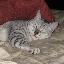

In [3]:
#testing dataset class logic and resizing pf images



root ='/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200'
#root=root+'/'+mode
root = os.path.join(root, 'train')

folders=[]
with open('/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/wnids.txt') as f:
        for fol_name in f:
            folders.append(fol_name.strip())

image_location=[]

for folder in folders:
    #temp_root=root+folder+'/images'
    temp_root = os.path.join(root, folder, "images")
    for img_file in os.listdir(temp_root):
                if img_file.endswith('.JPEG'):
                    full_path = os.path.join(temp_root, img_file)
                    image_location.append(full_path)

print(image_location[1])

image3= Image.open(image_location[1])
#print(image)
#image = np.array(image) 
#image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
#print(f"Image mode: {image3.mode}")
image3


In [4]:
image1=image3.resize((224,224),Image.BILINEAR)
image = np.array(image1) 
image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
image

tensor([[[0.2745, 0.2745, 0.2784,  ..., 0.0118, 0.0118, 0.0118],
         [0.2745, 0.2745, 0.2784,  ..., 0.0118, 0.0118, 0.0118],
         [0.2863, 0.2863, 0.2902,  ..., 0.0118, 0.0118, 0.0118],
         ...,
         [0.7843, 0.7843, 0.7882,  ..., 0.5216, 0.5137, 0.5137],
         [0.7529, 0.7529, 0.7569,  ..., 0.5020, 0.4941, 0.4941],
         [0.7529, 0.7529, 0.7569,  ..., 0.5020, 0.4941, 0.4941]],

        [[0.0863, 0.0863, 0.0902,  ..., 0.0078, 0.0078, 0.0078],
         [0.0863, 0.0863, 0.0902,  ..., 0.0078, 0.0078, 0.0078],
         [0.0980, 0.0980, 0.1020,  ..., 0.0078, 0.0078, 0.0078],
         ...,
         [0.7333, 0.7333, 0.7373,  ..., 0.4706, 0.4627, 0.4627],
         [0.7020, 0.7020, 0.7059,  ..., 0.4510, 0.4431, 0.4431],
         [0.7020, 0.7020, 0.7059,  ..., 0.4510, 0.4431, 0.4431]],

        [[0.0784, 0.0784, 0.0824,  ..., 0.0275, 0.0275, 0.0275],
         [0.0784, 0.0784, 0.0824,  ..., 0.0275, 0.0275, 0.0275],
         [0.0902, 0.0902, 0.0941,  ..., 0.0275, 0.0275, 0.

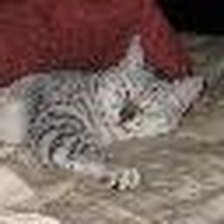

In [5]:
image2=image3.resize((224,224),Image.LANCZOS)
image2

In [6]:

image.shape


torch.Size([3, 224, 224])

In [7]:
#patches logic test
#patching calculation


#224/16=14
#14*14=196
#196*0.75=147 masked patches
#49 unmasked patches
def patchify(img):
    batch,channels,height,weight=img.shape
    patch_size=16
    patchh=height//patch_size
    patchw=weight//patch_size

    x = img.reshape(batch, channels, patchh, patch_size, patchw, patch_size)

    
    x = x.permute(0, 2, 4, 1, 3, 5)

    
    patches = x.reshape(batch, patchh * patchw, channels * patch_size * patch_size)

    return patches

In [8]:
class mydataset(Dataset):

    def __init__(self,mode='train'):
        root ='/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200'
        #root=root+'/'+mode
        root = os.path.join(root, mode)
        
        folders=[]
        with open('/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/wnids.txt') as f:
                for fol_name in f:
                    folders.append(fol_name.strip())

        self.image_location=[]
        if mode=='train':
            for folder in folders:
                #temp_root=root+folder+'/images'
                temp_root = os.path.join(root, folder, "images")
                for img_file in os.listdir(temp_root):
                            if img_file.endswith('.JPEG'):
                                full_path = os.path.join(temp_root, img_file)
                                self.image_location.append(full_path)
        else:
            temp_root=os.path.join(root,"images")
            for img_file in os.listdir(temp_root):
                            if img_file.endswith('.JPEG'):
                                full_path = os.path.join(temp_root, img_file)
                                self.image_location.append(full_path)
                
    
    def __len__(self):
        return len(self.image_location)

    
    def __getitem__(self,index):
        
        image= Image.open(self.image_location[index]).convert('RGB')
        image=image.resize((224,224),Image.BILINEAR)
        image = np.array(image) 
        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        return image 
    

In [9]:
traindata=mydataset('train')
train_data=DataLoader(traindata,shuffle=True,batch_size=64,pin_memory=True,num_workers=4,drop_last=True)

valdata=mydataset('val')
val_data=DataLoader(valdata,shuffle=False,batch_size=64,pin_memory=True,num_workers=4,drop_last=True)

In [10]:
class mymodel(nn.Module):

    def __init__(self):
        super().__init__()

        ###################################################

        self.encoder_hidden_dimension=768
        self.embedding=nn.Linear(self.encoder_hidden_dimension,self.encoder_hidden_dimension)
        self.patchestotal = 196
        self.positions = nn.Parameter(torch.randn(1, self.patchestotal, self.encoder_hidden_dimension))
        
        
        self.encoderhead=12
        self.no_encoderlayers=12
        
        self.encoderlayer=nn.TransformerEncoderLayer(
            d_model=self.encoder_hidden_dimension,
            nhead=self.encoderhead,
            dim_feedforward=self.encoder_hidden_dimension*3,
            batch_first=True
        )
        
        self.encoder=nn.TransformerEncoder(self.encoderlayer,num_layers=self.no_encoderlayers)

##########################################################
        
        self.mask_token = nn.Parameter(torch.randn(1, 1, self.encoder_hidden_dimension))
        self.decoderhead=6
        self.no_decoderlayer=12
        self.decoder_hidden_dim=384

        self.decoder_embed = nn.Linear(self.encoder_hidden_dimension, self.decoder_hidden_dim)
        
        self.decoderlayer=nn.TransformerEncoderLayer(
            d_model=self.decoder_hidden_dim,
            nhead=self.decoderhead,
            dim_feedforward=self.decoder_hidden_dim*3,
            batch_first=True
        )

        self.decoder=nn.TransformerEncoder(self.decoderlayer,num_layers=self.no_decoderlayer)
        self.decoder_positions = nn.Parameter(torch.randn(1, self.patchestotal, self.decoder_hidden_dim))

        self.output_layer = nn.Linear(self.decoder_hidden_dim, 768)

        self.enco_to_dec_dimension=nn.Linear(self.encoder_hidden_dimension,self.decoder_hidden_dim)



   #*******************************************************************************************************************************************************
    
    def forward(self,image_tensor):
        batch_size=image_tensor.shape[0]
        #print(image_tensor.shape)
        
        patches=patchify(image_tensor)
        patch_embedding=self.embedding(patches)

        patch_embedding=patch_embedding+self.positions

        
        unmask_indices = torch.tensor(random.sample(range(196), 49),device=image_tensor.device)
        unmask_patches = patch_embedding[:,unmask_indices,:]

        encoderoutput=self.encoder(unmask_patches)

        mask_indices=[]
        for i in range(196):
            if i not in unmask_indices:
                mask_indices.append(i)

        mask_indices_tensor=torch.tensor(mask_indices,device=image_tensor.device)
        
        mask_tokens = self.mask_token.expand(batch_size, 196-49, self.encoder_hidden_dimension)

        decoder_input = torch.zeros(batch_size, 196, 768, device=image_tensor.device)
        decoder_input[:, unmask_indices, :] = encoderoutput
        
        encoderoutput=self.enco_to_dec_dimension(encoderoutput)
        decoder_input[:, mask_indices, :] = mask_tokens

        
        decoder_input=self.decoder_embed(decoder_input)
        #print(encoderoutput.shape)
        #print(decoder_input.shape)
        decoder_input=decoder_input+self.decoder_positions
        decoder_output = self.decoder(
            decoder_input,  
            #memory=encoderoutput  
        )

        reconstruction = self.output_layer(decoder_output)  # (B, N, patch_dim)
        #print(reconstruction.shape)
        return reconstruction,mask_indices_tensor, unmask_indices
        

        
    

In [11]:
random_indices = torch.tensor(random.sample(range(196), 49))
random_indices
#selected_patches = patches[random_indices]

tensor([ 11, 152,  51,  69,  80,  39, 160, 108, 136, 140,  20, 174, 112,  24,
         29,  68,  67, 185,  54,  38,  47, 134,  49,   8,  85,  32, 141, 142,
        181,  99,  36,   4,  53,  92, 116,   2,  48, 158,  37, 137,  98,  21,
        110,  13,  65,  81, 126, 139,  14])

In [12]:
mymodel=mymodel()


mymodel = torch.nn.DataParallel(mymodel)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mymodel.to(device)

epochs=55
lossfunction=nn.MSELoss()

optimizer = torch.optim.AdamW(mymodel.parameters(),lr=3e-4,betas=(0.9, 0.95),weight_decay=0.05)

scaler = GradScaler()

/tmp/ipykernel_7064/3602208782.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [13]:
train_loss=[]
val_loss=[]


In [14]:
print("Training start")
for epoch in range(epochs):
    mymodel.train()
    totalloss=0
    #totalstd=0
    for images in train_data:
        
        images =images.to(device)


        optimizer.zero_grad()
        with autocast():
            results, maskedpatchslist, unmask_indices = mymodel(images)
            
            original_patches = patchify(images)
            masked_output = results[:, maskedpatchslist, :]
            original = original_patches[:, maskedpatchslist, :]
            loss = lossfunction(masked_output, original)
        
        
            #totalstd+=results.std()
            #print("loss",loss)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        totalloss+=loss.item()
        
    avgloss = totalloss / len(train_data)
    #avgstd=totalstd/len(train_data)
    train_loss.append(avgloss)


    mymodel.eval()
    total_valloss=0
    with torch.no_grad():
        for valimages in val_data:
            valimages= valimages.to(device)

            optimizer.zero_grad()
            result,maskedpatchslist,unmask_indices = mymodel(valimages)

            original_patches = patchify(valimages)

            masked_output=result[:,maskedpatchslist,:]
            original=original_patches[:, maskedpatchslist, :]
        
            valloss=lossfunction(masked_output,original)
            #valloss=lossfunction(original,new_maskedpatches)
    
            
            
            total_valloss+=valloss.item()
            
    avg_valloss = total_valloss / len(val_data)
    val_loss.append(avg_valloss)
    
    
    print(f"Epoch {epoch+1}, Train Loss: {avgloss:.4f}, Val Loss: {avg_valloss:.4f}")
    #print(f"STD {avgstd}")


    

Training start


/tmp/ipykernel_7064/3486898460.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1, Train Loss: 0.0732, Val Loss: 0.0710
Epoch 2, Train Loss: 0.0707, Val Loss: 0.0708
Epoch 3, Train Loss: 0.0706, Val Loss: 0.0709
Epoch 4, Train Loss: 0.0706, Val Loss: 0.0707
Epoch 5, Train Loss: 0.0706, Val Loss: 0.0708
Epoch 6, Train Loss: 0.0706, Val Loss: 0.0709
Epoch 7, Train Loss: 0.0706, Val Loss: 0.0708
Epoch 8, Train Loss: 0.0706, Val Loss: 0.0709
Epoch 9, Train Loss: 0.0706, Val Loss: 0.0707
Epoch 10, Train Loss: 0.0705, Val Loss: 0.0708
Epoch 11, Train Loss: 0.0705, Val Loss: 0.0708
Epoch 12, Train Loss: 0.0705, Val Loss: 0.0708
Epoch 13, Train Loss: 0.0706, Val Loss: 0.0707
Epoch 14, Train Loss: 0.0705, Val Loss: 0.0707
Epoch 15, Train Loss: 0.0705, Val Loss: 0.0708
Epoch 16, Train Loss: 0.0705, Val Loss: 0.0708
Epoch 17, Train Loss: 0.0705, Val Loss: 0.0709
Epoch 18, Train Loss: 0.0705, Val Loss: 0.0708
Epoch 19, Train Loss: 0.0705, Val Loss: 0.0708
Epoch 20, Train Loss: 0.0705, Val Loss: 0.0708
Epoch 21, Train Loss: 0.0705, Val Loss: 0.0709
Epoch 22, Train Loss: 

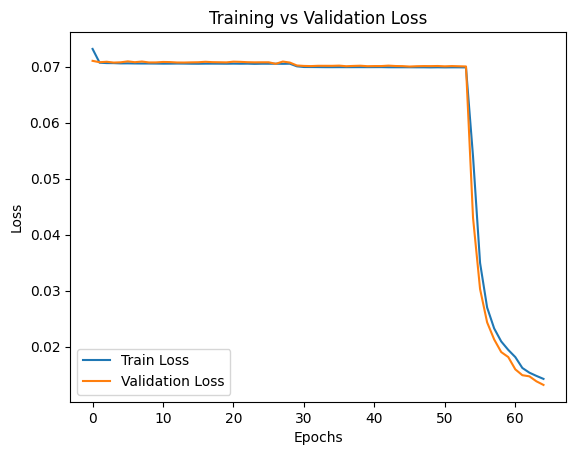

In [21]:
import matplotlib.pyplot as plt

plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()


In [23]:
# Suppose 'model' is your trained PyTorch model

# 1️⃣ Save only weights (recommended)
torch.save(mymodel.state_dict(), "model5.pth")

# 2️⃣ Save entire model (quick demo)
#torch.save(model, "model5.pt")


In [19]:
print("Training start")
for epoch in range(55,65):
    mymodel.train()
    totalloss=0
    #totalstd=0
    for images in train_data:
        
        images =images.to(device)


        optimizer.zero_grad()
        with autocast():
            results, maskedpatchslist, unmask_indices = mymodel(images)
            
            original_patches = patchify(images)
            masked_output = results[:, maskedpatchslist, :]
            original = original_patches[:, maskedpatchslist, :]
            loss = lossfunction(masked_output, original)
        
        
            #totalstd+=results.std()
            #print("loss",loss)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        totalloss+=loss.item()
        
    avgloss = totalloss / len(train_data)
    #avgstd=totalstd/len(train_data)
    train_loss.append(avgloss)


    mymodel.eval()
    total_valloss=0
    with torch.no_grad():
        for valimages in val_data:
            valimages= valimages.to(device)

            optimizer.zero_grad()
            result,maskedpatchslist,unmask_indices = mymodel(valimages)

            original_patches = patchify(valimages)

            masked_output=result[:,maskedpatchslist,:]
            original=original_patches[:, maskedpatchslist, :]
        
            valloss=lossfunction(masked_output,original)
            #valloss=lossfunction(original,new_maskedpatches)
    
            
            
            total_valloss+=valloss.item()
            
    avg_valloss = total_valloss / len(val_data)
    val_loss.append(avg_valloss)
    
    
    print(f"Epoch {epoch+1}, Train Loss: {avgloss:.4f}, Val Loss: {avg_valloss:.4f}")
    #print(f"STD {avgstd}")


    

Training start


/tmp/ipykernel_7064/27812224.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 56, Train Loss: 0.0350, Val Loss: 0.0303
Epoch 57, Train Loss: 0.0270, Val Loss: 0.0244
Epoch 58, Train Loss: 0.0233, Val Loss: 0.0213
Epoch 59, Train Loss: 0.0210, Val Loss: 0.0191
Epoch 60, Train Loss: 0.0194, Val Loss: 0.0182
Epoch 61, Train Loss: 0.0182, Val Loss: 0.0160
Epoch 62, Train Loss: 0.0162, Val Loss: 0.0149
Epoch 63, Train Loss: 0.0154, Val Loss: 0.0147
Epoch 64, Train Loss: 0.0148, Val Loss: 0.0138
Epoch 65, Train Loss: 0.0143, Val Loss: 0.0132
